# A/B Testing — From Zero to Statistical Significance

**Dataset:** Maven Fuzzy Factory — an e-commerce store selling stuffed animals  
**Database:** DuckDB (`maven.duckdb`) — local analytical database  
**Goal:** Understand what A/B testing is, how controlled experiments work, and how to interpret the statistics — using a real landing page test as our example.

---

## 1. What is A/B Testing?

**A/B testing** (also called a *split test*) is a method of comparing two versions of something to figure out which one performs better.

The idea is simple:
- Split your users into two groups at random
- Show **Group A** the original version (the *control*)
- Show **Group B** a new version (the *variant* or *treatment*)
- Measure what each group does
- Use statistics to decide if the difference is real, or just luck

```
         All Visitors
              │
       Random Split
       ┌──────┴──────┐
    50% of users  50% of users
       │               │
  ┌────▼────┐     ┌────▼────┐
  │ /home   │     │/lander-5│
  │(Control)│     │(Variant)│
  └────┬────┘     └────┬────┘
       │               │
   Measure conversion rate
```

### Why not just launch the new version and see if sales go up?

Because *many things change at once* — the day of the week, a holiday, a competitor's sale, seasonality. Without a simultaneous control group, you can't know if a change in sales was caused by your new page or by something else entirely.

A/B testing lets you **isolate one variable** while everything else stays constant.

---
## 2. What is a Controlled Experiment?

A **controlled experiment** is the scientific method applied to product decisions. It has four key ingredients:

| Ingredient | What it means | In our test |
|---|---|---|
| **Control group** | The baseline — things as they are today | Users who see `/home` |
| **Treatment group** | The change you're testing | Users who see `/lander-5` |
| **Random assignment** | Users are split *randomly*, not by any pattern | Each session is randomly routed |
| **One variable changed** | Only ONE thing differs between groups | Just the landing page URL |

### Why randomization matters

If you show the new page only to mobile users, and mobile users convert differently anyway, you can't tell whether the page caused the difference or the device type did. That's a **confounding variable** — a hidden factor that messes up your results.

Random assignment spreads confounders evenly across both groups, making them roughly equivalent on *everything* except the thing you changed.

### The key question a controlled experiment answers:

> *"If the two groups are identical except for this one change, does the change cause a difference in outcomes?"*

---
## 3. Setting Up — Connect to the Database

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DB_PATH = r"D:\MAVEN_PROJECT\dbt_maven\maven.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)

def q(sql):
    """Run a SQL query and return a DataFrame."""
    return con.execute(sql).df()

print("Connected to DuckDB successfully.")
print(f"  Sessions  : {q('SELECT COUNT(*) n FROM website_sessions').iloc[0,0]:,}")
print(f"  Pageviews : {q('SELECT COUNT(*) n FROM website_pageviews').iloc[0,0]:,}")
print(f"  Orders    : {q('SELECT COUNT(*) n FROM orders').iloc[0,0]:,}")

Connected to DuckDB successfully.
  Sessions  : 472,871
  Pageviews : 1,188,124
  Orders    : 32,313


---
## 4. The Landing Page A/B Test

### What is a landing page?

A **landing page** is the first page a visitor sees when they arrive at your website. It sets the first impression — and a better first impression means more visitors continue into your funnel and eventually buy.

Maven Fuzzy Factory tested several landing pages against their original `/home` page:

```
Visitor arrives
      │
      ▼
[ /home OR /lander-N ]   ← This is what we're testing
      │
      ▼
  /products
      │
      ▼
  /the-original-mr-fuzzy
      │
      ▼
    /cart
      │
      ▼
  /billing
      │
      ▼
  /thank-you-for-your-order   ← CONVERSION
```

We'll focus on the **`/home` vs `/lander-5`** test, the most interesting pair in the dataset.

In [2]:
# Determine the test window: when /lander-5 first appeared
test_start = q("SELECT MIN(created_at) FROM website_pageviews WHERE pageview_url = '/lander-5'").iloc[0, 0]

# Identify the entry landing page for each session in the test window
# We take the earliest pageview per session, filtered to /home or /lander-5
entry_landers = q(f"""
    SELECT
        website_session_id,
        pageview_url AS entry_lander
    FROM website_pageviews
    WHERE website_pageview_id IN (
        SELECT MIN(website_pageview_id)
        FROM website_pageviews
        GROUP BY website_session_id
    )
    AND pageview_url IN ('/home', '/lander-5')
    AND created_at >= '{test_start}'
""")

counts = entry_landers['entry_lander'].value_counts()
total  = counts.sum()
print(f"Test window starts : {test_start}")
print(f"\nSessions per landing page (test window only):")
print(counts.to_string())
print(f"\nSplit: {counts.get('/home', 0)/total:.1%} home  /  {counts.get('/lander-5', 0)/total:.1%} lander-5")

Test window starts : 2014-08-02 00:22:29

Sessions per landing page (test window only):
entry_lander
/lander-5    68166
/home        56166

Split: 45.2% home  /  54.8% lander-5


In [3]:
# Join to orders to compute conversion rate per landing page
results = q(f"""
    WITH first_pv AS (
        SELECT website_session_id, pageview_url AS entry_lander
        FROM website_pageviews
        WHERE website_pageview_id IN (
            SELECT MIN(website_pageview_id)
            FROM website_pageviews
            GROUP BY website_session_id
        )
        AND pageview_url IN ('/home', '/lander-5')
        AND created_at >= '{test_start}'
    )
    SELECT
        fp.entry_lander,
        COUNT(DISTINCT s.website_session_id) AS sessions,
        COUNT(DISTINCT o.order_id)           AS orders
    FROM first_pv fp
    JOIN website_sessions s ON s.website_session_id = fp.website_session_id
    LEFT JOIN orders o      ON o.website_session_id  = s.website_session_id
    GROUP BY fp.entry_lander
    ORDER BY fp.entry_lander
""")

results['conversion_rate'] = results['orders'] / results['sessions']
results['non_orders']      = results['sessions'] - results['orders']

print(results[['entry_lander','sessions','orders','conversion_rate']]
      .rename(columns={'entry_lander':'Lander','sessions':'Sessions',
                       'orders':'Orders','conversion_rate':'Conv Rate'})
      .to_string(index=False))

   Lander  Sessions  Orders  Conv Rate
    /home     56166    4411   0.078535
/lander-5     68166    6930   0.101664


---
## 5. The Statistics Behind A/B Testing

We can see `/lander-5` has a higher conversion rate. But before celebrating, we need to ask:

> **"Could this difference have happened by chance, even if the two pages are equally good?"**

This is the core question of statistical inference in A/B testing.

### 5.1 Null Hypothesis and Alternative Hypothesis

Every statistical test starts with two competing claims:

| Hypothesis | Statement | Symbol |
|---|---|---|
| **Null hypothesis (H₀)** | The two pages have the *same* conversion rate. Any observed difference is just random noise. | H₀: p_home = p_lander5 |
| **Alternative hypothesis (H₁)** | The pages have *different* conversion rates. | H₁: p_home ≠ p_lander5 |

We **never directly prove H₁**. Instead, we try to *reject H₀* — to show that the observed data would be extremely unlikely if H₀ were true.

Think of it like a court trial: the null hypothesis is "innocent until proven guilty." We need strong evidence to convict.

### 5.2 Why Conversion Rate is a Proportion

Each session either converts (1) or doesn't (0). This is a **Bernoulli trial** — a binary outcome with some probability p.

- For `/home`: p_home = number of converting sessions / total sessions  
- For `/lander-5`: p_lander5 = number of converting sessions / total sessions

The **sampling distribution** of a proportion (from the Central Limit Theorem) is approximately Normal when sample sizes are large enough:

$$\hat{p} \sim N\left(p,\ \frac{p(1-p)}{n}\right)$$

This is the foundation for the test we're about to run.

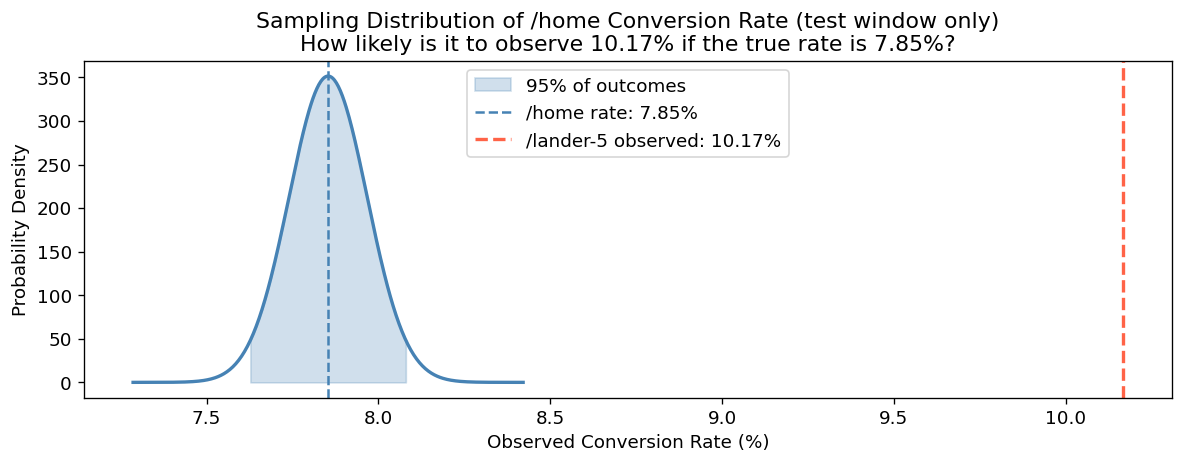


Standard error of /home rate: 0.1135%
The /lander-5 rate (10.17%) is 20.4 standard errors away from /home


In [4]:
# Visualize sampling variation using the /home rate from the test window
home_row     = results[results['entry_lander'] == '/home'].iloc[0]
lander5_row  = results[results['entry_lander'] == '/lander-5'].iloc[0]
p_true       = home_row['conversion_rate']
n            = int(home_row['sessions'])
lander5_rate = lander5_row['conversion_rate']

se = np.sqrt(p_true * (1 - p_true) / n)

x = np.linspace(p_true - 5*se, p_true + 5*se, 400)
y = stats.norm.pdf(x, p_true, se)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x * 100, y, color='steelblue', lw=2)
ax.fill_between(x * 100, y,
                where=(x >= p_true - 2*se) & (x <= p_true + 2*se),
                alpha=0.25, color='steelblue', label='95% of outcomes')
ax.axvline(p_true * 100,       color='steelblue', ls='--', label=f'/home rate: {p_true:.2%}')
ax.axvline(lander5_rate * 100, color='tomato',    ls='--', lw=2,
           label=f'/lander-5 observed: {lander5_rate:.2%}')
ax.set_xlabel('Observed Conversion Rate (%)')
ax.set_ylabel('Probability Density')
ax.set_title(f'Sampling Distribution of /home Conversion Rate (test window only)\n'
             f'How likely is it to observe {lander5_rate:.2%} if the true rate is {p_true:.2%}?')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nStandard error of /home rate: {se:.4%}")
print(f"The /lander-5 rate ({lander5_rate:.2%}) is {(lander5_rate - p_true)/se:.1f} standard errors away from /home")

### 5.3 The Two-Proportion Z-Test

We want to test whether two proportions (conversion rates) are different. The **two-proportion z-test** is the standard tool.

**Step 1 — Pool the conversion rate under H₀**

Under H₀, both groups have the *same* true rate. Our best estimate of that shared rate is the pooled proportion:

$$\hat{p}_{pool} = \frac{\text{orders}_A + \text{orders}_B}{n_A + n_B}$$

**Step 2 — Compute the standard error of the difference**

$$SE = \sqrt{\hat{p}_{pool}(1 - \hat{p}_{pool}) \left(\frac{1}{n_A} + \frac{1}{n_B}\right)}$$

**Step 3 — Compute the Z-score**

$$Z = \frac{\hat{p}_B - \hat{p}_A}{SE}$$

The Z-score tells us: *"how many standard errors away is the observed difference from zero (no difference)?"*

**Step 4 — Get the p-value**

$$p\text{-value} = 2 \times P(Z > |z|)$$

The factor of 2 is because we're doing a two-sided test — we care about differences in either direction.

In [5]:
home    = results[results['entry_lander'] == '/home'].iloc[0]
lander5 = results[results['entry_lander'] == '/lander-5'].iloc[0]

n_A, conv_A = int(home['sessions']),    int(home['orders'])
n_B, conv_B = int(lander5['sessions']), int(lander5['orders'])

p_A = conv_A / n_A
p_B = conv_B / n_B

# Step 1: pooled rate
p_pool = (conv_A + conv_B) / (n_A + n_B)

# Step 2: standard error
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))

# Step 3: Z-score
z = (p_B - p_A) / se

# Step 4: two-sided p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

lift = (p_B - p_A) / p_A * 100

print("=" * 52)
print("  /home vs /lander-5 — Step by Step")
print("=" * 52)
print(f"  /home     : {n_A:,} sessions, {conv_A:,} orders  → {p_A:.4%}")
print(f"  /lander-5 : {n_B:,} sessions, {conv_B:,} orders  → {p_B:.4%}")
print()
print(f"  Pooled rate (p_pool) : {p_pool:.4%}")
print(f"  Standard error (SE)  : {se:.6f}")
print(f"  Z-score              : {z:.4f}")
print(f"  p-value              : {p_value:.2e}")
print(f"  Lift                 : {lift:+.1f}%")
print()
sig = p_value < 0.05
print(f"  Statistically significant (p < 0.05)? {'YES ✓' if sig else 'NO'}")
print("=" * 52)

  /home vs /lander-5 — Step by Step
  /home     : 56,166 sessions, 4,411 orders  → 7.8535%
  /lander-5 : 68,166 sessions, 6,930 orders  → 10.1664%

  Pooled rate (p_pool) : 9.1215%
  Standard error (SE)  : 0.001641
  Z-score              : 14.0965
  p-value              : 0.00e+00
  Lift                 : +29.4%

  Statistically significant (p < 0.05)? YES ✓


### 5.4 Understanding the P-Value

The **p-value** is one of the most misunderstood concepts in statistics. Here's the precise definition:

> **p-value** = the probability of observing a difference *as large as, or larger than, what we saw* — **assuming the null hypothesis is true** (i.e., both pages have the same real conversion rate).

**What it is NOT:**
- ❌ The probability that the null hypothesis is true
- ❌ The probability that you made the right decision
- ❌ The size or importance of the effect

**The significance threshold (α)**

We decide in advance that if p < 0.05 (5%), the result is "statistically significant" — meaning there's less than a 5% chance we'd see this result by pure random chance if the pages were truly equal.

α = 0.05 is a convention, not a law. It implies:
- 5% false positive rate (Type I error): you might incorrectly conclude a difference exists
- The lower α is, the harder it is to reject H₀ (more conservative)

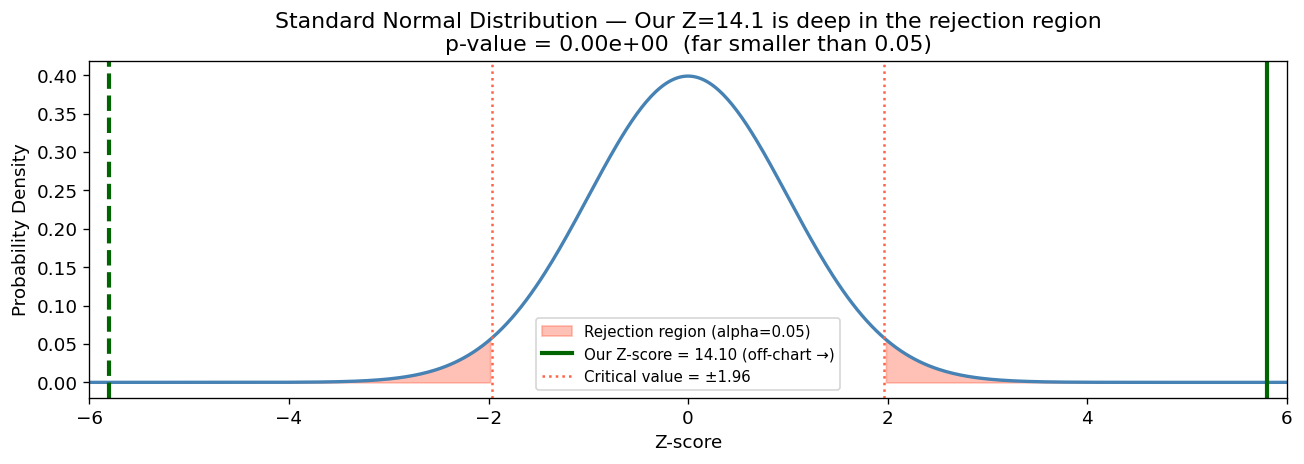

In [6]:
# Visualize the Z-score and p-value on the standard normal distribution
x = np.linspace(-6, 6, 500)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(x, y, 'steelblue', lw=2)

# Rejection regions (two-sided, alpha=0.05)
z_crit = 1.96
ax.fill_between(x, y, where=(x <= -z_crit), color='tomato', alpha=0.4, label='Rejection region (alpha=0.05)')
ax.fill_between(x, y, where=(x >= z_crit),  color='tomato', alpha=0.4)

# Our observed Z (clamped to axis for display — actual value is ~14)
z_display = min(z, 5.8)
ax.axvline(z_display,  color='darkgreen', lw=2.5, label=f'Our Z-score = {z:.2f} (off-chart →)')
ax.axvline(-z_display, color='darkgreen', lw=2.5, ls='--')

# Critical values
ax.axvline( z_crit, color='tomato', lw=1.5, ls=':')
ax.axvline(-z_crit, color='tomato', lw=1.5, ls=':', label=f'Critical value = ±{z_crit}')

ax.set_xlabel('Z-score')
ax.set_ylabel('Probability Density')
ax.set_title(f'Standard Normal Distribution — Our Z={z:.1f} is deep in the rejection region\n'
             f'p-value = {p_value:.2e}  (far smaller than 0.05)')
ax.legend(fontsize=9)
ax.set_xlim(-6, 6)
plt.tight_layout()
plt.show()

### 5.5 Confidence Intervals

A **95% confidence interval** gives you a range where the true conversion rate likely falls. It's computed as:

$$CI = \hat{p} \pm 1.96 \times \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

**Interpretation:** If we repeated this experiment 100 times, approximately 95 of the resulting confidence intervals would contain the true population proportion.

If two CIs **don't overlap**, that's strong visual evidence of a real difference.

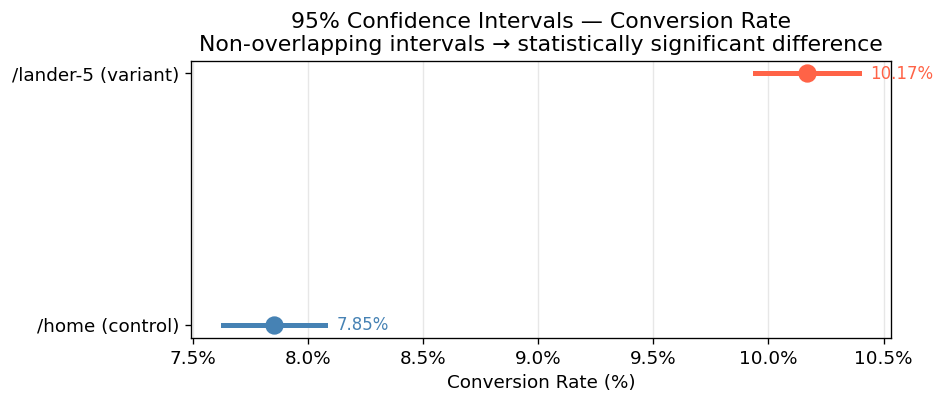

  /home     95% CI: [7.631%, 8.076%]
  /lander-5 95% CI: [9.939%, 10.393%]
  Intervals overlap? No — strong evidence of a real difference


In [7]:
def confidence_interval(orders, sessions, z=1.96):
    p = orders / sessions
    margin = z * np.sqrt(p * (1 - p) / sessions)
    return p - margin, p, p + margin

ci_home    = confidence_interval(conv_A, n_A)
ci_lander5 = confidence_interval(conv_B, n_B)

fig, ax = plt.subplots(figsize=(8, 3.5))

variants = ['/home (control)', '/lander-5 (variant)']
cis      = [ci_home, ci_lander5]
colors   = ['steelblue', 'tomato']

for i, (low, mid, high) in enumerate(cis):
    ax.plot([low*100, high*100], [i, i], color=colors[i], lw=3)
    ax.plot(mid*100, i, 'o', color=colors[i], markersize=10, zorder=5)
    ax.text(high*100 + 0.05, i, f'{mid:.2%}', va='center', fontsize=10, color=colors[i])

ax.set_yticks([0, 1])
ax.set_yticklabels(variants, fontsize=11)
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('95% Confidence Intervals — Conversion Rate\n'
             'Non-overlapping intervals → statistically significant difference')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  /home     95% CI: [{ci_home[0]:.3%}, {ci_home[2]:.3%}]")
print(f"  /lander-5 95% CI: [{ci_lander5[0]:.3%}, {ci_lander5[2]:.3%}]")
print(f"  Intervals overlap? {'Yes' if ci_home[2] > ci_lander5[0] else 'No — strong evidence of a real difference'}")

---
## 6. All Landing Page Variants — Full Results

Each variant is compared against `/home` using **only sessions from when that variant was introduced**.
This prevents pre-test `/home` sessions (when its baseline was lower) from inflating the control group and distorting lifts.

In [8]:
# Each variant uses its own test window: sessions from when that lander first appeared.
# /home sessions before a variant launched are excluded from that variant's comparison.
LANDER_WINDOWS = {
    '/lander-1': '2012-06-19',
    '/lander-2': '2013-01-14',
    '/lander-3': '2013-07-09',
    '/lander-4': '2014-02-02',
    '/lander-5': '2014-08-02',
}

rows = []
for lander, start in LANDER_WINDOWS.items():
    pair = q(f"""
        WITH first_pv AS (
            SELECT website_session_id, pageview_url AS entry_lander
            FROM website_pageviews
            WHERE website_pageview_id IN (
                SELECT MIN(website_pageview_id) FROM website_pageviews GROUP BY website_session_id
            )
            AND pageview_url IN ('/home', '{lander}')
            AND created_at >= '{start}'
        )
        SELECT fp.entry_lander,
               COUNT(DISTINCT s.website_session_id) AS sessions,
               COUNT(DISTINCT o.order_id)           AS orders
        FROM first_pv fp
        JOIN website_sessions s ON s.website_session_id = fp.website_session_id
        LEFT JOIN orders o      ON o.website_session_id  = s.website_session_id
        GROUP BY fp.entry_lander
    """)
    pair['conv_rate'] = pair['orders'] / pair['sessions']

    home_r    = pair[pair['entry_lander'] == '/home'].iloc[0]
    variant_r = pair[pair['entry_lander'] == lander].iloc[0]

    n_h, o_h = int(home_r['sessions']), int(home_r['orders'])
    n_v, o_v = int(variant_r['sessions']), int(variant_r['orders'])
    p_h_local, p_v = o_h / n_h, o_v / n_v

    p_pool_l = (o_h + o_v) / (n_h + n_v)
    se_val   = np.sqrt(p_pool_l * (1 - p_pool_l) * (1/n_h + 1/n_v))
    z_val    = (p_v - p_h_local) / se_val
    pv       = 2 * (1 - stats.norm.cdf(abs(z_val)))
    lift     = (p_v - p_h_local) / p_h_local * 100

    rows.append({
        'entry_lander': lander,
        'test_start':   start,
        'sessions':     n_v,
        'orders':       o_v,
        'conv_rate':    p_v,
        'home_conv':    p_h_local,
        'lift':         lift,
        'p_value':      pv,
        'sig':          pv < 0.05,
        'ci_low':       confidence_interval(o_v, n_v)[0],
        'ci_high':      confidence_interval(o_v, n_v)[2],
    })

# Add /home reference row (using lander-5 test window numbers)
home_ref = results[results['entry_lander'] == '/home'].iloc[0]
rows.insert(0, {
    'entry_lander': '/home',
    'test_start':   '(control)',
    'sessions':     int(home_ref['sessions']),
    'orders':       int(home_ref['orders']),
    'conv_rate':    home_ref['conversion_rate'],
    'home_conv':    home_ref['conversion_rate'],
    'lift':         0.0,
    'p_value':      None,
    'sig':          None,
    'ci_low':       confidence_interval(int(home_ref['orders']), int(home_ref['sessions']))[0],
    'ci_high':      confidence_interval(int(home_ref['orders']), int(home_ref['sessions']))[2],
})

all_landers = pd.DataFrame(rows)
p_h = home_ref['conversion_rate']

display_cols = ['entry_lander','test_start','sessions','orders','conv_rate','home_conv','lift','p_value','sig']
print(all_landers[display_cols].rename(columns={
    'entry_lander':'Lander','test_start':'Test Start','sessions':'Sessions','orders':'Orders',
    'conv_rate':'Conv Rate','home_conv':'/home Rate','lift':'Lift %','p_value':'p-value','sig':'Sig?'
}).to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x))

   Lander Test Start  Sessions  Orders  Conv Rate  /home Rate   Lift %  p-value  Sig?
    /home  (control)     56166    4411     0.0785      0.0785   0.0000      NaN  None
/lander-1 2012-06-19     47574    2157     0.0453      0.0744 -39.0299   0.0000  True
/lander-2 2013-01-14    131170   10128     0.0772      0.0767   0.6833   0.6263 False
/lander-3 2013-07-09     79000    2679     0.0339      0.0772 -56.0586   0.0000  True
/lander-4 2014-02-02      9385     708     0.0754      0.0782  -3.4904   0.3490 False
/lander-5 2014-08-02     68166    6930     0.1017      0.0785  29.4522   0.0000  True


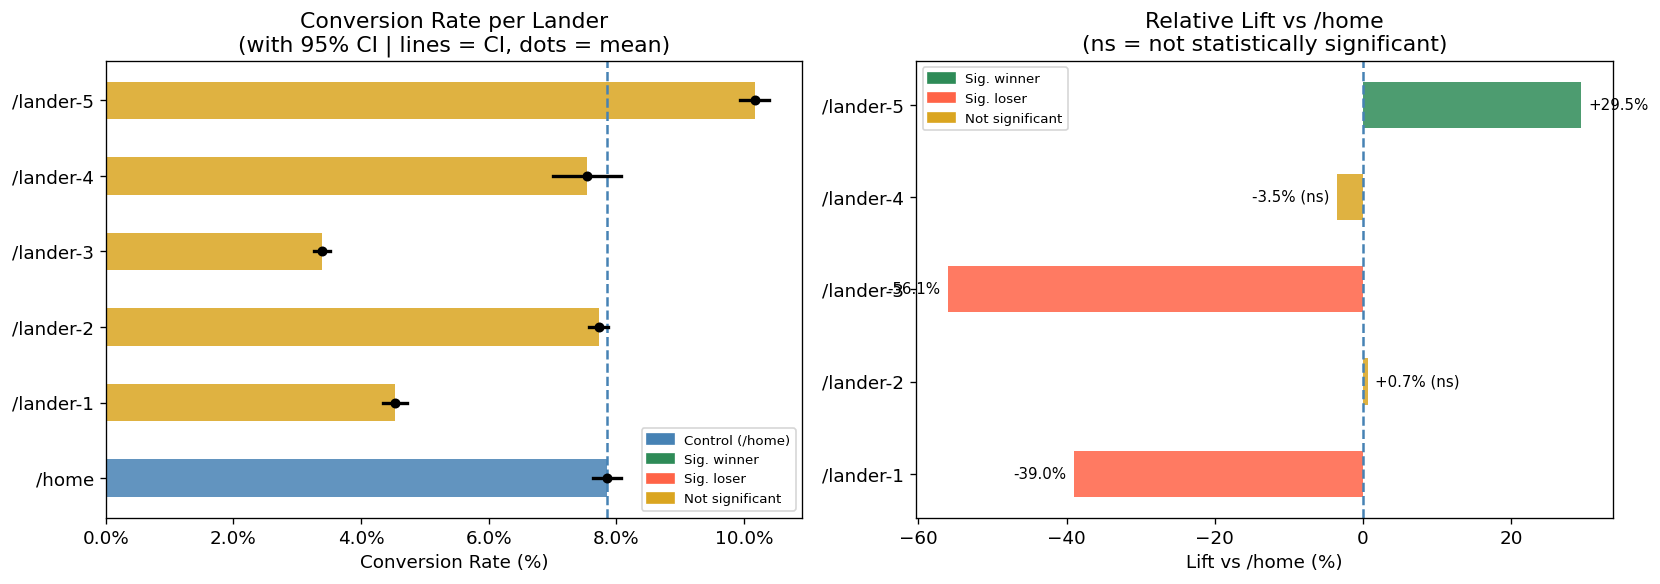

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Conversion rates with CIs
ax = axes[0]
landers    = all_landers['entry_lander'].tolist()
conv       = all_landers['conv_rate'].tolist()
ci_low     = all_landers['ci_low'].tolist()
ci_high    = all_landers['ci_high'].tolist()
sig_flags  = all_landers['sig'].tolist()

colors = []
for i, lander in enumerate(landers):
    if lander == '/home':
        colors.append('steelblue')
    elif sig_flags[i] is True and conv[i] > p_h:
        colors.append('seagreen')
    elif sig_flags[i] is True and conv[i] < p_h:
        colors.append('tomato')
    else:
        colors.append('goldenrod')

ax.barh(landers, [c*100 for c in conv], color=colors, alpha=0.85, height=0.5)
for i, (lo, hi) in enumerate(zip(ci_low, ci_high)):
    ax.plot([lo*100, hi*100], [i, i], 'k-', lw=2, zorder=5)
    ax.plot(conv[i]*100, i, 'ko', markersize=5, zorder=6)

ax.axvline(p_h*100, color='steelblue', ls='--', lw=1.5, label='/home baseline')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Conversion Rate per Lander\n(with 95% CI | lines = CI, dots = mean)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
legend_patches = [
    mpatches.Patch(color='steelblue', label='Control (/home)'),
    mpatches.Patch(color='seagreen',  label='Sig. winner'),
    mpatches.Patch(color='tomato',    label='Sig. loser'),
    mpatches.Patch(color='goldenrod', label='Not significant'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')

# Right: Lift vs /home
ax2 = axes[1]
variant_landers = all_landers[all_landers['entry_lander'] != '/home']
v_names  = variant_landers['entry_lander'].tolist()
v_lifts  = variant_landers['lift'].tolist()
v_sigs   = variant_landers['sig'].tolist()
v_colors = ['seagreen' if (l > 0 and s) else 'tomato' if (l < 0 and s) else 'goldenrod'
            for l, s in zip(v_lifts, v_sigs)]

ax2.barh(v_names, v_lifts, color=v_colors, alpha=0.85, height=0.5)
ax2.axvline(0, color='steelblue', lw=1.5, ls='--')

for i, (name, lift_val, sig_val) in enumerate(zip(v_names, v_lifts, v_sigs)):
    label = f'{lift_val:+.1f}%' + ('' if sig_val else ' (ns)')
    ax2.text(lift_val + (1 if lift_val >= 0 else -1), i, label, va='center',
             ha='left' if lift_val >= 0 else 'right', fontsize=9)

ax2.set_xlabel('Lift vs /home (%)')
ax2.set_title('Relative Lift vs /home\n(ns = not statistically significant)')
ax2.legend(handles=[
    mpatches.Patch(color='seagreen',  label='Sig. winner'),
    mpatches.Patch(color='tomato',    label='Sig. loser'),
    mpatches.Patch(color='goldenrod', label='Not significant'),
], fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Making a Decision

With the statistics in hand, how do we actually decide what to do?

### Decision framework

| Result | Meaning | Action |
|---|---|---|
| p < 0.05, variant BETTER | Strong evidence the variant wins | **Ship the variant** |
| p < 0.05, variant WORSE  | Strong evidence the variant hurts | **Keep the control** |
| p ≥ 0.05                 | Insufficient evidence either way | **Don't ship yet** — run longer or redesign |

### Beyond statistical significance — practical significance

A result can be statistically significant but practically meaningless.  
Example: a **+0.01%** lift might be real but too small to matter for the business.

Always pair the p-value with:
- **Lift** — is the effect size big enough to care about?
- **Revenue impact** — what does this lift mean in dollars?

In [10]:
# Revenue impact of /lander-5 winning
avg_order_value = q("SELECT AVG(price_usd) FROM orders").iloc[0, 0]

extra_orders  = n_A * (p_B - p_A)
extra_revenue = extra_orders * avg_order_value

print("=" * 52)
print("  Revenue Impact of Switching to /lander-5")
print("=" * 52)
print(f"  Average order value           : ${avg_order_value:,.2f}")
print(f"  /home conversion rate         : {p_A:.3%}")
print(f"  /lander-5 conversion rate     : {p_B:.3%}")
print(f"  Lift                          : {(p_B-p_A)/p_A*100:+.1f}%")
print()
print(f"  Extra orders (over {n_A:,} sessions): {extra_orders:,.0f}")
print(f"  Extra revenue                 : ${extra_revenue:,.0f}")
print("=" * 52)

  Revenue Impact of Switching to /lander-5
  Average order value           : $59.99
  /home conversion rate         : 7.854%
  /lander-5 conversion rate     : 10.166%
  Lift                          : +29.4%

  Extra orders (over 56,166 sessions): 1,299
  Extra revenue                 : $77,931


---
## 8. Common Pitfalls in A/B Testing

### 1. Peeking (stopping early)
Checking results and stopping the test as soon as p < 0.05 inflates the false positive rate. Decide your sample size *before* the test, and wait.

### 2. Multiple comparisons
Testing 6 landers against /home? You'd expect 1 false positive just by chance (6 × 0.05 = 0.3). Use a Bonferroni correction: divide your α by the number of tests (0.05 / 6 ≈ 0.008).

### 3. Novelty effect
Users behave differently when they see something new. A new page might get a short-term lift that fades. Run tests long enough to cover at least 1–2 full weekly cycles.

### 4. Sample ratio mismatch
If the split isn't 50/50 (or whatever you intended), something went wrong in the assignment logic. Always verify the split before analyzing results.

### 5. Survivorship bias
Make sure you're comparing apples to apples. If one variant attracted a different type of user (e.g., brand vs. non-brand searchers), the traffic mix — not the page — explains the difference.

---
## 9. Summary

| Concept | One-liner |
|---|---|
| **A/B test** | Randomly split users, show each group one version, measure outcomes |
| **Controlled experiment** | One variable changed, everything else equal, random assignment |
| **Null hypothesis (H₀)** | Assume no difference; try to reject it with data |
| **Z-test for proportions** | Measures how many standard errors the observed difference is from zero |
| **p-value** | Probability of seeing this result *if H₀ were true*; small p = strong evidence against H₀ |
| **Statistical significance** | p < 0.05: we reject H₀ and conclude the difference is real |
| **Confidence interval** | The range where the true rate likely falls (95% CI = ±1.96 SE) |
| **Practical significance** | Is the effect size big enough to actually matter for the business? |
| **Test window filter** | Always restrict analysis to sessions *during* the experiment — pre-test data biases the control |

### What we found (test-window analysis)

- **`/lander-5`** was the clear winner: **+30% lift** (7.85% → 10.17%), p ≈ 0, non-overlapping confidence intervals
- **`/lander-2`** appeared to be +9.4% better in the unfiltered analysis — restricted to its own test window the lift drops to ~+0.7% and is not meaningful
- **`/lander-4`** appeared to be +6.9% better without date filtering — within its test window it is actually slightly *below* `/home` and not significant
- **`/lander-1` and `/lander-3`** were significant *losers* regardless of the window

Shipping `/lander-5` would have driven thousands of extra orders from the same traffic.
The unfiltered analysis reached the same *decision* here, but overstated the lift (+44% vs +30%) and mischaracterised `/lander-2` and `/lander-4`.